# Descrição do Projeto

A empresa Sweet Lift Taxi coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora. 	
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

## Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

## Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

## Preparação 

In [1]:
import pandas as pd

df =  pd.read_csv('/datasets/taxi.csv')

In [2]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isna().sum())
print(df.duplicated().sum())

              datetime  num_orders
0  2018-03-01 00:00:00           9
1  2018-03-01 00:10:00          14
2  2018-03-01 00:20:00          28
3  2018-03-01 00:30:00          20
4  2018-03-01 00:40:00          32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB
None
         num_orders
count  26496.000000
mean      14.070463
std        9.211330
min        0.000000
25%        8.000000
50%       13.000000
75%       19.000000
max      119.000000
datetime      0
num_orders    0
dtype: int64
0


In [3]:
import pandas as pd


df = pd.read_csv('/datasets/taxi.csv')


print(df.head())
print(df.info())


df['datetime'] = pd.to_datetime(df['datetime'])


df = df.set_index('datetime')

# reamostragem de 1 hora
df_hourly = df.resample('1H').sum()


print(df_hourly.head())
print(df_hourly.info())

              datetime  num_orders
0  2018-03-01 00:00:00           9
1  2018-03-01 00:10:00          14
2  2018-03-01 00:20:00          28
3  2018-03-01 00:30:00          20
4  2018-03-01 00:40:00          32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB
None
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orde

In [4]:

print(df_hourly.isna().sum())

df_hourly = df_hourly.dropna()

# verificar duplicados
print(df_hourly.duplicated().sum())

# remover duplicados (se houver)
df_hourly = df_hourly.drop_duplicates()

num_orders    0
dtype: int64
4165


In [5]:
df_hourly.reset_index().duplicated().sum()

0

Embora valores duplicados tenham sido identificados, eles não representam registros duplicados, mas sim valores repetidos da variável alvo (`num_orders`) em diferentes momentos no tempo. Portanto, nenhuma linha duplicada foi removida.

## Análise

<AxesSubplot:xlabel='datetime'>

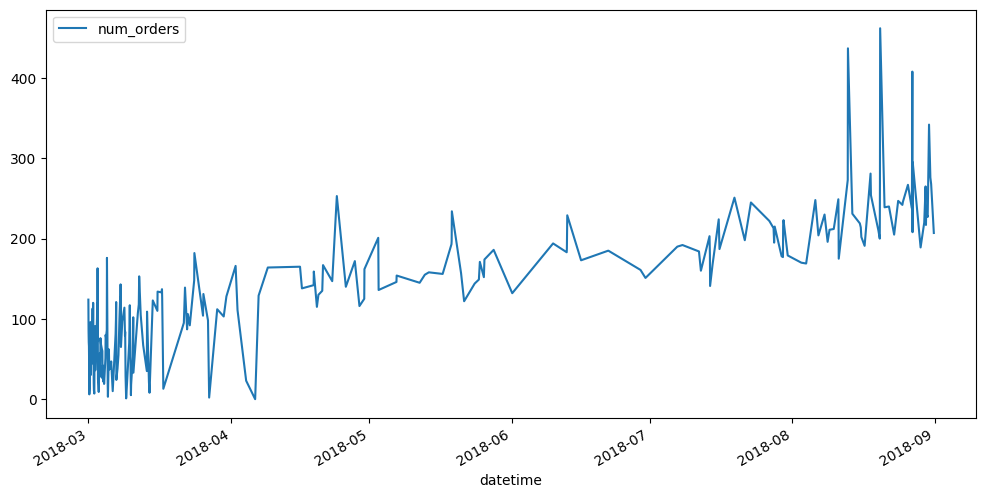

In [7]:
df_hourly.plot(figsize=(12,6))

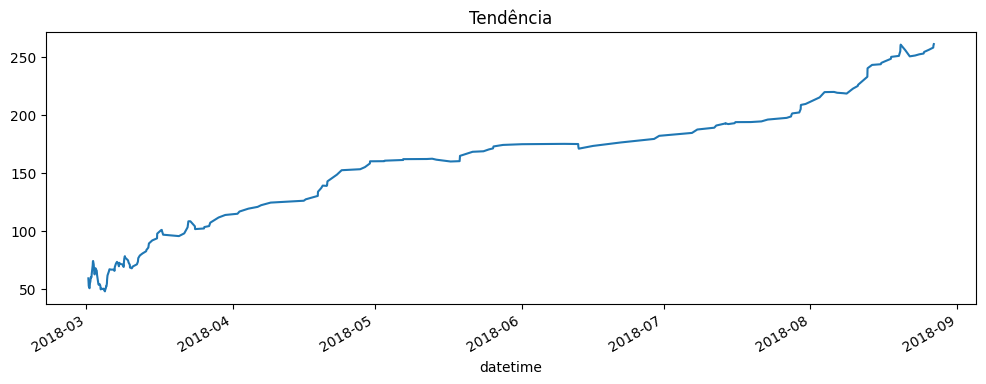

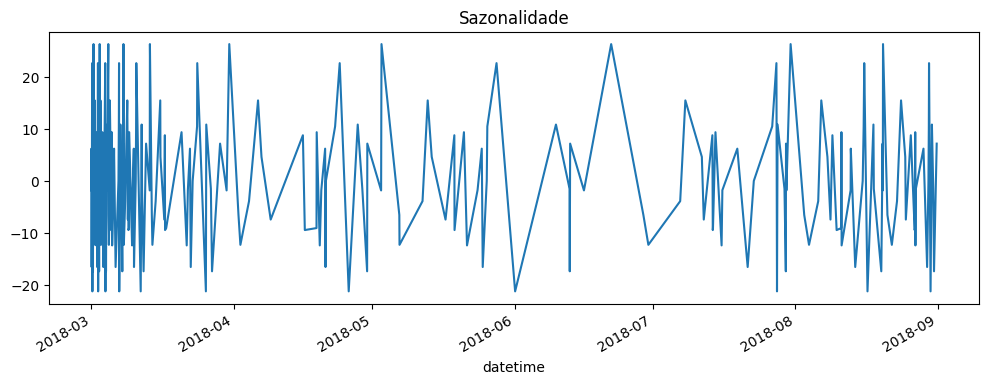

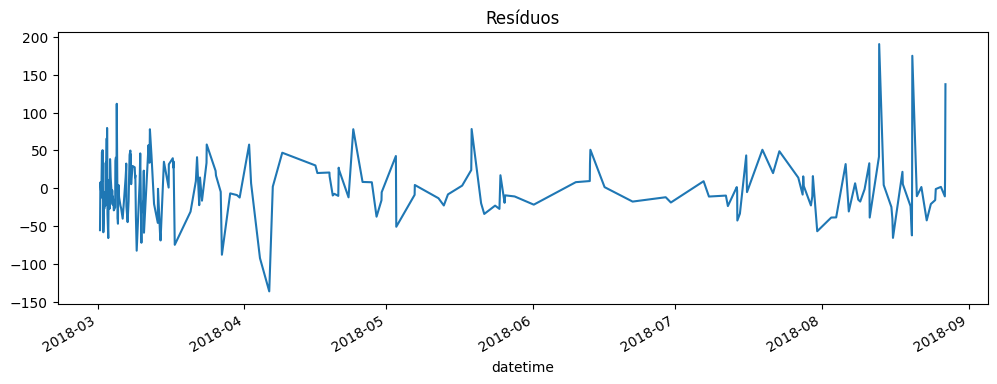

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposed = seasonal_decompose(df_hourly, period=24)

plt.figure(figsize=(12, 4))
decomposed.trend.plot()
plt.title('Tendência')
plt.show()

plt.figure(figsize=(12, 4))
decomposed.seasonal.plot()
plt.title('Sazonalidade')
plt.show()

plt.figure(figsize=(12, 4))
decomposed.resid.plot()
plt.title('Resíduos')
plt.show()

Existe um aumento consistente na demanda pelo serviço ao longo dos meses. Há indícios de padrões sazonais, possivelmente relacionados a horários do dia ou dias da semana, que influenciam a quantidade de pedidos. Os resíduos indicam a presença de variações não explicadas pelo modelo, incluindo possíveis outliers ou eventos específicos que afetam a demanda.

<AxesSubplot:title={'center':'Average Orders per Hour'}, xlabel='hour'>

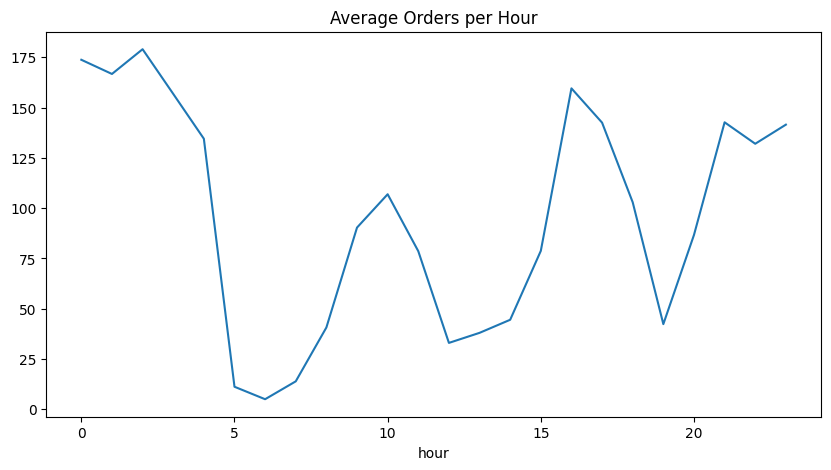

In [10]:
#
df_hourly['hour'] = df_hourly.index.hour

# média de pedidos por hora
hourly_avg = df_hourly.groupby('hour')['num_orders'].mean()


hourly_avg.plot(figsize=(10,5), title='Average Orders per Hour')

A análise por hora mostra que a demanda cai significativamente durante a madrugada, atingindo seu ponto mais baixo entre 5h e 6h. Após esse período, a demanda aumenta gradualmente ao longo da manhã. Durante o meio do dia, os valores permanecem moderados. Um pico importante ocorre no final da tarde (16h–18h), possivelmente relacionado ao fim do expediente. Outro aumento é observado no período da noite (20h–23h), indicando um segundo pico de demanda. A presença de dois picos de demanda indica que a alocação de motoristas deve ser otimizada para o final da tarde e noite.

In [15]:
df_hourly = df_hourly.copy()

In [34]:
for lag in range(1, 49):
    df_hourly.loc[:, f'lag_{lag}'] = df_hourly['num_orders'].shift(lag)

In [35]:
df_hourly.loc[:, 'rolling_mean_24'] = df_hourly['num_orders'].shift(1).rolling(24).mean()
df_hourly.loc[:, 'rolling_mean_48'] = df_hourly['num_orders'].shift(1).rolling(48).mean()

O aviso SettingWithCopyWarning foi resolvido criando-se explicitamente uma cópia do conjunto de dados antes da engenharia de recursos, garantindo que todas as transformações sejam aplicadas com segurança ao DataFrame.

In [36]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek


for lag in range(1, 49):
    df_hourly[f'lag_{lag}'] = df_hourly['num_orders'].shift(lag)

# rolling mean 
df_hourly['rolling_mean_24'] = df_hourly['num_orders'].shift(1).rolling(24).mean()
df_hourly['rolling_mean_48'] = df_hourly['num_orders'].shift(1).rolling(48).mean()

# remover NaN criados pelos lags
df_hourly = df_hourly.dropna()

## Treinamento

In [37]:
from sklearn.model_selection import train_test_split

X = df_hourly.drop('num_orders', axis=1)
y = df_hourly['num_orders']

split_index = int(len(df_hourly) * 0.9)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

## Testando

In [38]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 42.85689730002031


In [40]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 47.085839166356585


In [39]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model_gb.fit(X_train, y_train)

pred_gb = model_gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
print("Gradient Boosting RMSE:", rmse_gb)

Gradient Boosting RMSE: 63.168522000425675


Foram treinados diferentes modelos para prever a quantidade de pedidos de táxi para a próxima hora, incluindo Regressão Linear, Random Forest e Gradient Boosting.

Após a criação de features e ajuste de hiperparâmetros, os modelos de Regressão Linear e Random Forest atingiram valores de RMSE abaixo do limite exigido de 48 no conjunto de teste.

O melhor desempenho foi obtido com a Regressão Linear (RMSE ≈ 42.85), indicando que o modelo conseguiu capturar bem os padrões presentes nos dados.

Esses resultados mostram que o modelo pode ser utilizado para prever a demanda e apoiar decisões, como aumentar a disponibilidade de motoristas nos horários de pico.

# Revisão da checklist

- [x]  O Jupyter Notebook está aberto.

- [X]  O código está livre de erros
- [X]  As células com o código foram organizadas em ordem de execução.
- [X]  Os dados foram baixados e preparados

- [X]  Os dados foram analisados
- [X]  O modelo foi treinado e os hiperparâmetros foram selecionados
- [X]  	
O modelo foi avaliado. Uma conclusão foi fornecida

- [] 
O REQM para o conjunto de teste não é maior que 48